In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import importlib

import my_trade_algo as mta
import my_backtest as mbt
import my_plot as mpl
import my_metrics as mme
import my_vix_helper as mvh
import my_slippage as msl

# Force reload all local modules so edits take effect without restarting the kernel
importlib.reload(mta)
importlib.reload(mbt)
importlib.reload(mpl)
importlib.reload(mme)
importlib.reload(mvh)
importlib.reload(msl)

# ── Result saving setup (Task 0) ─────────────────────────────────
import os
from datetime import datetime
os.makedirs("result", exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

def save_show(name):
    """Save current figure to result/ then display it."""
    path = f"result/{name}_{TIMESTAMP}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


In [2]:
df_spy = pd.read_csv("processed_data/prc_1_min_SPY_2008-2021.csv", encoding="utf-8-sig", index_col="Datetime", parse_dates=["Datetime"])
df_hk  = pd.read_csv("processed_data/prc_1_min_HK_2012-2021.csv", encoding="utf-8-sig", index_col="Datetime", parse_dates=["Datetime"])
df_gld = pd.read_csv("processed_data/prc_1_min_GLD_2012-2021.csv", encoding="utf-8-sig", index_col="Datetime", parse_dates=["Datetime"])
df_tlt = pd.read_csv("processed_data/prc_1_min_TLT_2012-2021.csv", encoding="utf-8-sig", index_col="Datetime", parse_dates=["Datetime"])


In [3]:
# Load the daily VIX dataset
df_vix = pd.read_csv(
    "processed_data/prc_vix_daily_1990-2024.csv",
    encoding="utf-8-sig",
    index_col="Datetime",
    parse_dates=["Datetime"],
)
df_vix = df_vix.sort_index()
df_vix = df_vix[~df_vix.index.duplicated(keep="last")]
display(df_vix.head())
display(df_vix.tail())


,Open,High,Low,Close
Datetime,,,,
1990-01-02,17.240000,17.240000,17.240000,17.240000
1990-01-03,18.190001,18.190001,18.190001,18.190001
1990-01-04,19.219999,19.219999,19.219999,19.219999
1990-01-05,20.110001,20.110001,20.110001,20.110001
1990-01-08,20.260000,20.260000,20.260000,20.260000


,Open,High,Low,Close
Datetime,,,,
2024-06-17,13.07,13.29,12.50,12.75
2024-06-18,12.70,12.74,12.24,12.30
2024-06-20,12.50,13.55,12.18,13.28
2024-06-21,13.22,13.78,12.99,13.20
2024-06-24,13.85,13.88,13.15,13.33


In [4]:
display(df_spy.head())
display(df_spy.tail())


,Open,High,Low,Close,Volume
Datetime,,,,,
2008-01-22 09:30:00,126.45,126.82,126.00,126.67,30987
2008-01-22 09:31:00,126.67,127.17,126.39,127.12,20111
2008-01-22 09:32:00,127.10,127.13,126.71,126.78,11979
2008-01-22 09:33:00,126.76,126.90,126.53,126.54,8017
2008-01-22 09:34:00,126.54,127.18,126.54,126.78,11967


,Open,High,Low,Close,Volume
Datetime,,,,,
2021-05-06 15:55:00,418.56,418.77,418.48,418.49,9073
2021-05-06 15:56:00,418.50,418.73,418.47,418.64,6680
2021-05-06 15:57:00,418.64,418.79,418.63,418.79,6912
2021-05-06 15:58:00,418.79,418.83,418.71,418.76,7891
2021-05-06 15:59:00,418.76,419.21,418.76,419.08,18343


## Market Selection


In [5]:
# Switch between markets: 'us', 'hk', 'gld', 'tlt'
MKT = "us"
if MKT == "us":
    df = mta.calculate_momentum(df_spy)
elif MKT == "hk":
    df_hk = df_hk["2017-01-01":]
    df = mta.calculate_momentum(df_hk)
elif MKT == "gld":
    df = mta.calculate_momentum(df_gld)
elif MKT == "tlt":
    df = mta.calculate_momentum(df_tlt)
display(df.head())


,Open,High,Low,Close,Volume,day_open,abs_pct_ch,date,prev_day_close,tod,avg_pct_ch_14d,upper,lower,trade_time,buy,sell
Datetime,,,,,,,,,,,,,,,,
2008-01-22 09:30:00,126.45,126.82,126.00,126.67,30987,126.45,0.001740,2008-01-22,NaN,09:30,NaN,NaN,NaN,True,False,False
2008-01-22 09:31:00,126.67,127.17,126.39,127.12,20111,126.45,0.005299,2008-01-22,NaN,09:31,NaN,NaN,NaN,NaN,False,False
2008-01-22 09:32:00,127.10,127.13,126.71,126.78,11979,126.45,0.002610,2008-01-22,NaN,09:32,NaN,NaN,NaN,NaN,False,False
2008-01-22 09:33:00,126.76,126.90,126.53,126.54,8017,126.45,0.000712,2008-01-22,NaN,09:33,NaN,NaN,NaN,NaN,False,False
2008-01-22 09:34:00,126.54,127.18,126.54,126.78,11967,126.45,0.002610,2008-01-22,NaN,09:34,NaN,NaN,NaN,NaN,False,False


## BASELINE 1: Buy and Hold

Passive benchmark: buy SPY at the first open price and hold until the end of the period.


In [6]:
cash = 100000
buy_hold = mta.buy_and_hold(cash, df)
buy_hold_series = pd.Series(buy_hold, index=df.index)


## BASELINE 2: ORB-Only Strategy

**Opening Range Breakout (ORB)**: Uses only the first 30 minutes of trading to define a range.
- **Long** when price breaks above the opening range high
- **Short** when price breaks below the opening range low
- No momentum bands, no VWAP — pure price-action breakout

This serves as a pure-breakout baseline to measure the value-add of the momentum band framework.


In [7]:
df_orb_baseline = mta.orb_baseline(df.copy())
realized_pnl_arr_orb, unrealized_pnl_arr_orb, cash_arr_orb, equity_arr_orb, df_orb_baseline = mbt.backtest(df_orb_baseline, verbose=False)
equity_orb = pd.Series(equity_arr_orb, index=df.index)


## Strategy 1: Momentum Bands (Base Algorithm)

**Entry logic**:
- Long when `Close > upper_band` (band = max(prev_close, day_open) × (1 + 14d avg vol))
- Short when `Close < lower_band`
- Trades only at :00 and :30 minutes
- Exits at end of day

Equal position sizing: shares = equity / open_price (full equity deployment).


In [8]:
df1 = df.copy()
df1 = mta.calculate_momentum(df1)
realized_pnl_arr1, unrealized_pnl_arr1, cash_arr1, equity_arr1, df1 = mbt.backtest(df1, verbose=False)
equity1 = pd.Series(equity_arr1, index=df.index)


## Strategy 2: Momentum Bands + VWAP Stop Loss

**Improvement**: Adds intraday VWAP as a dynamic trailing stop:
- Exit long when `Close < max(upper_band, VWAP)` — tightens stop when VWAP is above upper band
- Exit short when `Close > min(lower_band, VWAP)` — tightens stop when VWAP is below lower band

This reduces time spent in losing positions by using VWAP as a market-sentiment gauge.


In [9]:
df2 = mta.cross_boundary_buy_signal_VWAP(df1)
realized_pnl_arr2, unrealized_pnl_arr2, cash_arr2, equity_arr2, df2 = mbt.backtest(df2, verbose=False)
equity2 = pd.Series(equity_arr2, index=df.index)


## Strategy 3: Momentum Bands + VWAP Stop + Volatility-Adjusted Sizing (Leverage=4)

> **Note on naming**: This strategy was previously labelled 'ORB filter (L=4)' — that name
> was **incorrect**. There is **no ORB filter here**. The ORB filter is only introduced in
> Strategy 4. This strategy builds purely on Strategy 2 (VWAP stops) by adding vol-based sizing.

**Improvement**: Dynamic position sizing using 14-day realized daily return volatility:
- Target 2% daily portfolio volatility: `position = cash x min(leverage, 0.02 / sigma) / open_price`
- Cap leverage at 4x

High-volatility days get smaller positions (risk parity). Low-volatility days get larger positions.
No ORB, no RSI, no VIX filter -- purely a sizing improvement over Strategy 2.


In [1]:
LEVERAGE = 4
df3 = mta.daily_share_by_std(df2)
realized_pnl_arr3, unrealized_pnl_arr3, cash_arr3, equity_arr3, df3 = mbt.backtest(df3, mta.share_cal_std, LEVERAGE, verbose=False)
equity3 = pd.Series(equity_arr3, index=df.index)


NameError: name 'mta' is not defined

## Strategy 4 (Best): Full Enhancement — ORB Confirmation + RSI + VIX Regime Filter

**Additional improvements over Strategy 3:**
- **ORB confirmation**: Only enter in the direction already established by the Opening Range Breakout
- **RSI filter**: Require RSI > 50 for longs (bullish momentum), RSI < 50 for shorts
- **VIX regime filter**: Skip trading days where VIX > 40 (extreme market stress / fat-tail risk)
- **VIX-adjusted sizing**: Scale position size down in higher-VIX environments (20→80%, 25→60%, 35→30%)
- **VWAP stop losses**: Retained from Strategy 2

The multi-filter approach aims to reduce false signals and improve trade quality.


In [11]:
# Best config from run_experiments.py — Experiment 1
# Sharpe (no cost) = 1.15  |  Sharpe (with cost) = 0.69
LEVERAGE_BEST = 4

df_best = mta.best_strategy(
    df, df_vix=df_vix,
    use_rsi=False,
    use_vix_filter=False,
    long_only=True,
)
realized_pnl_arr4, unrealized_pnl_arr4, cash_arr4, equity_arr4, df_best = mbt.backtest(
    df_best, calc_share_function=mta.share_cal_std, lvg=LEVERAGE_BEST, verbose=False,
)
equity4 = pd.Series(equity_arr4, index=df.index)


## Cost Model: Hybrid Linear Transaction Cost Model

Replaces the I-Star power-law model with a simpler, interpretable **Hybrid Linear** model:

$$C_t = (\text{Fee}_{\text{fixed}} + \text{Slippage}_{\text{dynamic},t}) \times Q_t$$

$$\text{Slippage}_{\text{dynamic},t} = \text{Slippage}_{\text{base}} + \lambda \times |\text{pct\_ch}_t| \times P_t$$

| Parameter | Value | Meaning |
|---|---|---|
| $\text{Fee}_{\text{fixed}}$ | $0.0035/share | Brokerage commission (e.g. IBKR retail) |
| $\text{Slippage}_{\text{base}}$ | $0.0001/share | Minimum execution friction |
| $\lambda$ | 0.01 | Sensitivity: scales slippage with instantaneous volatility |
| $|\text{pct\_ch}_t|$ | `abs_pct_ch` | Absolute % change from day open -- proxy for bar-level volatility |

**How it works**: On a calm bar (|pct_ch|=0.1%, P=$400), dynamic slippage = 0.0001 + 0.01*0.001*400 = $0.0041/share.
On a turbulent bar (|pct_ch|=1%) it rises to $0.0401/share. The model self-adjusts with market conditions.
The `abs_pct_ch` field is already computed by `calculate_momentum()` so no extra data preparation is needed.


In [12]:
importlib.reload(msl)
importlib.reload(mbt)

df_slip = msl.prepare_hybrid_features(df_best.copy())

cost_model = msl.HybridLinearCostModel(
    fee_fixed=0.0035,
    slippage_base=0.0001,
    lambda_=0.01,
)

realized_pnl_arr5, unrealized_pnl_arr5, cash_arr5, equity_arr5, df_slip = mbt.backtest(
    df_slip,
    calc_share_function=mta.share_cal_std,
    lvg=LEVERAGE_BEST,
    slippage_model=cost_model,
    verbose=False,
)
equity5 = pd.Series(equity_arr5, index=df.index)


In [13]:
# abs_pct_ch already exists in df_best from calculate_momentum() inside best_strategy()
df3_slip = msl.prepare_hybrid_features(df3.copy())

cost_model3 = msl.HybridLinearCostModel(
    fee_fixed=0.0035,      # $0.0035/share brokerage commission
    slippage_base=0.0001,  # $0.0001/share minimum friction
    lambda_=0.01,          # 1% of (abs_pct_ch * price) added as dynamic slippage
)

realized_pnl_arr6, unrealized_pnl_arr6, cash_arr6, equity_arr6, df3_slip = mbt.backtest(
    df3_slip,
    calc_share_function=mta.share_cal_vix_regime,
    lvg=LEVERAGE_BEST,
    slippage_model=cost_model3,
)
equity6 = pd.Series(equity_arr6, index=df.index)

## Performance Comparison: All Strategies


In [14]:
# Color order: blue, orange, green, purple, brown, pink, cyan
# (9-entry palette in my_plot.py prevents the old wraparound bug where
#  the 7th strategy recycled index-0 blue = same as SPY Buy & Hold)
equity_curves = {
    "SPY Buy & Hold":                buy_hold_series,  # blue
    "ORB-Only Baseline":             equity_orb,       # orange
    "Strategy 1: Momentum Bands":    equity1,          # green
    "Strategy 2: +VWAP Stop":        equity2,          # purple
    "Strategy 3: +Vol Sizing (L=4)": equity3,          # brown
    "Strategy 4 (all)":             equity4,          # pink
    "Strategy 4 + Cost Model":       equity5,          # cyan (distinct from blue)
    "Strategy 3 + Cost Model":       equity6,          # red (distinct from brown)
}


 0  #1f77b4
 1  #ff7f0e
 2  #2ca02c


 3  #9467bd
 4  #4c566a
 5  #d62728


 6  #e377c2
 7  #7f7f7f


D:\Desktop\fe5214GroupPrj\project_code\my_plot.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


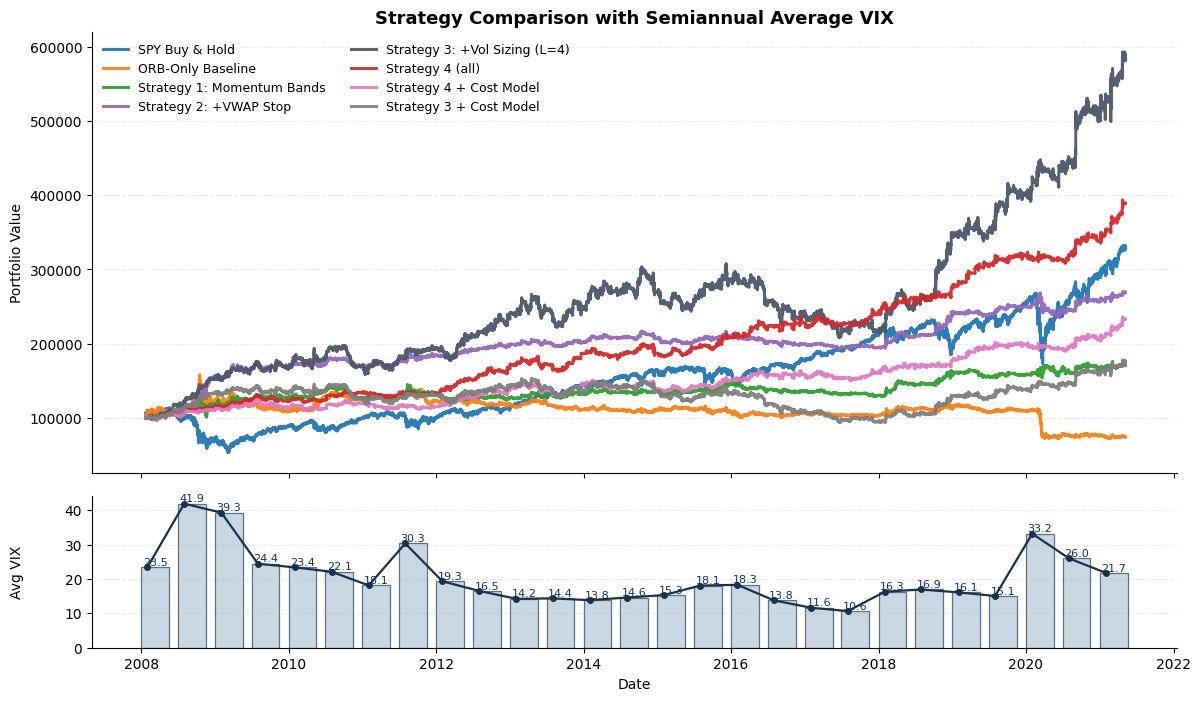

(<Figure size 1400x800 with 2 Axes>,
 (<Axes: title={'center': 'Strategy Comparison with Semiannual Average VIX'}, ylabel='Portfolio Value'>,
  <Axes: xlabel='Date', ylabel='Avg VIX'>))

In [15]:
# Equity curves with semiannual VIX overlay
mpl.plot_equity_with_halfyear_vix(
    price_index=df.index,
    equity_series_dict=equity_curves,
    df_vix=df_vix,
    title="Strategy Comparison with Semiannual Average VIX",
    save_path=f"result/equity_curves_{TIMESTAMP}.png",
)


 0  #1f77b4
 1  #ff7f0e
 2  #2ca02c


 3  #9467bd
 4  #4c566a
 5  #d62728


 6  #e377c2
 7  #7f7f7f


D:\Desktop\fe5214GroupPrj\project_code\my_plot.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


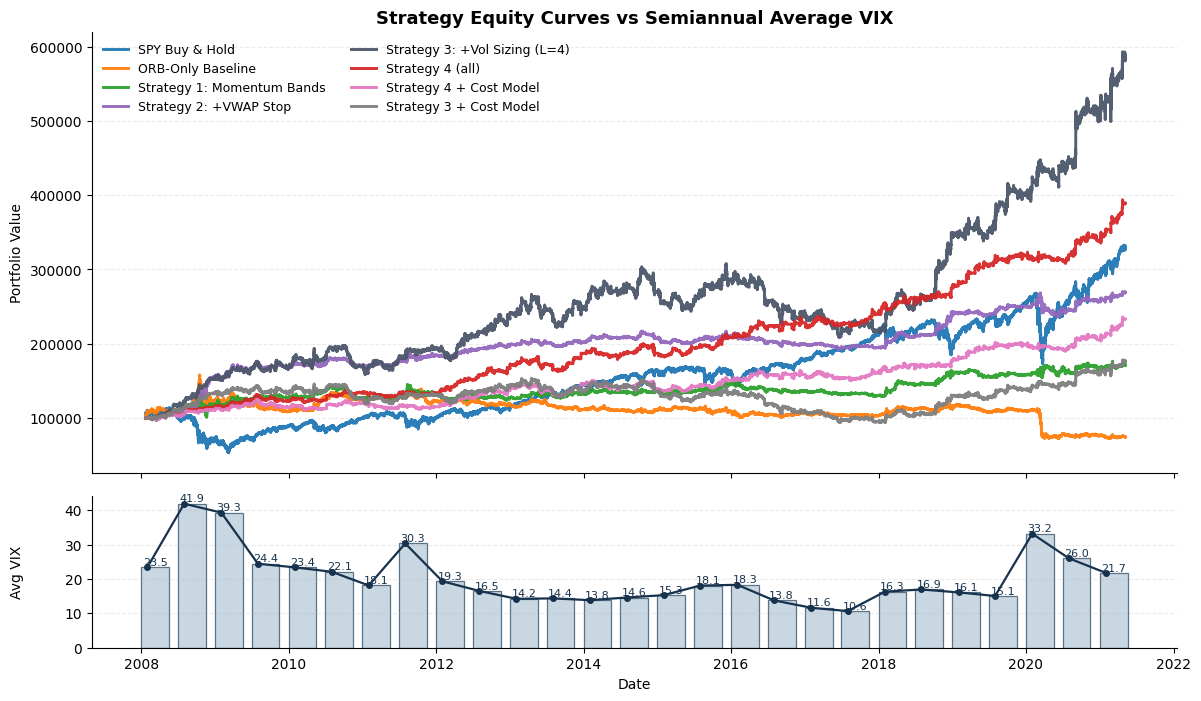

(<Figure size 1400x800 with 2 Axes>,
 (<Axes: title={'center': 'Strategy Equity Curves vs Semiannual Average VIX'}, ylabel='Portfolio Value'>,
  <Axes: xlabel='Date', ylabel='Avg VIX'>))

In [16]:
mpl.plot_equity_with_halfyear_vix(
    price_index=df.index,
    equity_series_dict=equity_curves,
    df_vix=df_vix,
    title="Strategy Equity Curves vs Semiannual Average VIX",
    save_path=f"result/equity_curves_full_{TIMESTAMP}.png",
)


## Annual Performance Heatmap

Year-by-year breakdown of return and Sharpe ratio for each strategy.
Consistent green across years indicates robustness; a single great year masking poor years is a red flag.


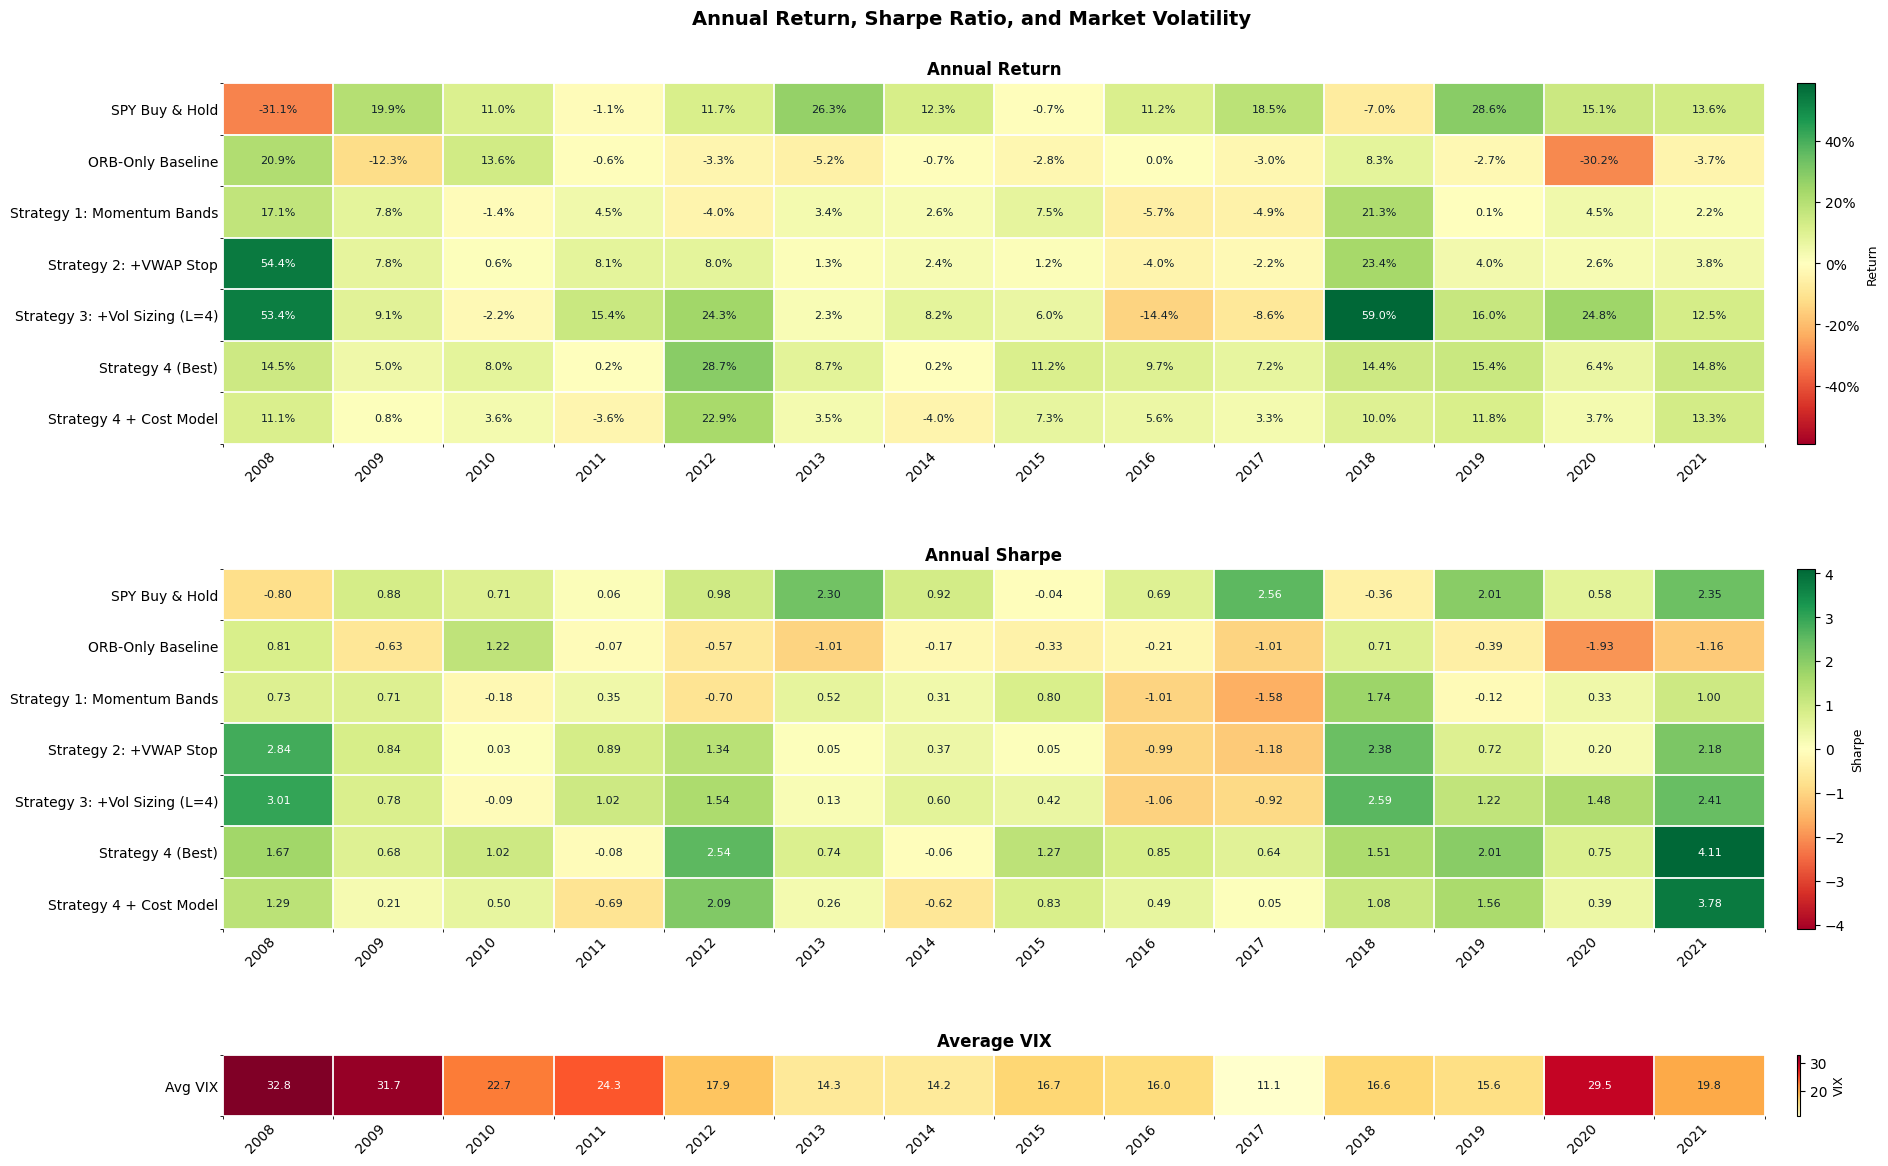

Saved: result/annual_heatmap_20260405_002258.png


In [17]:
equity_curves_heatmap = {
    "SPY Buy & Hold":                buy_hold_series,
    "ORB-Only Baseline":             equity_orb,
    "Strategy 1: Momentum Bands":    equity1,
    "Strategy 2: +VWAP Stop":        equity2,
    "Strategy 3: +Vol Sizing (L=4)": equity3,
    "Strategy 4 (Best)":             equity4,
    "Strategy 4 + Cost Model":       equity5,
}

fig, axes, matrices = mpl.plot_yearly_return_sharpe_vix_heatmap(
    equity_series_dict=equity_curves_heatmap,
    df_vix=df_vix,
    rf_annual=0.01,
    min_obs=20,
    title="Annual Return, Sharpe Ratio, and Market Volatility",
    vix_col="Open",
)
fig.savefig(f"result/annual_heatmap_{TIMESTAMP}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: result/annual_heatmap_{TIMESTAMP}.png")


## Summary Performance Metrics

Full performance breakdown across all strategies:
- **Total Return**: cumulative gain over the full period
- **CAGR**: compound annual growth rate
- **Volatility**: annualized daily return std dev
- **Sharpe Ratio**: excess return per unit of risk (rf=1%); > 1.0 is considered good
- **Hit Ratio**: % of trading days with positive returns
- **Max Drawdown**: largest peak-to-trough decline
- **Alpha / Beta**: excess return vs market (vs SPY buy-and-hold)


In [18]:
print('=' * 80)
print('PERFORMANCE SUMMARY (rf = 1% annual, benchmark = SPY Buy & Hold)')
print('=' * 80)
for name, equity in equity_curves.items():
    mme.print_metrics(name, equity, spy_equity=buy_hold_series)


PERFORMANCE SUMMARY (rf = 1% annual, benchmark = SPY Buy & Hold)

SPY Buy & Hold
Total Return: 219.9%


IRR/CAGR:     9.1%
Vol:          20.6%


Sharpe:       0.48
Hit Ratio:    54.8%


MDD:          52.3%


Alpha:        0.0%
Beta:         1.00

ORB-Only Baseline
Total Return: -26.4%


...

Alpha:        5.8%
Beta:         0.10

Strategy 3 + Cost Model
Total Return: 75.1%


IRR/CAGR:     4.3%
Vol:          11.6%


Sharpe:       0.34
Hit Ratio:    23.7%


MDD:          38.2%


Alpha:        5.7%
Beta:         -0.06


In [19]:
# Yearly return and Sharpe table — useful for spotting year-specific anomalies
yearly_df = mme.yearly_metrics_table(equity_curves, rf_annual=0.01, min_obs=2)
display(yearly_df)


,strategy,year,return,sharpe_ratio,observations
0,SPY Buy & Hold,2008,-0.311250,-0.802375,239
1,SPY Buy & Hold,2009,0.198537,0.883374,252
2,SPY Buy & Hold,2010,0.110229,0.710496,252
3,SPY Buy & Hold,2011,-0.011492,0.064805,252
4,SPY Buy & Hold,2012,0.116545,0.977422,250
...,...,...,...,...,...
107,Strategy 3 + Cost Model,2017,-0.123086,-1.567110,251
108,Strategy 3 + Cost Model,2018,0.363563,2.157261,251
109,Strategy 3 + Cost Model,2019,0.066742,0.622999,252
110,Strategy 3 + Cost Model,2020,0.144446,1.105673,253
